In [55]:
import wandb
from glob import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [56]:
ra = [10000, 100000, 1000000, 5000000]
scale = [3.9, 6.9, 11.6, 19.8]
type = ["dist", "nusselt", "reward"]

# read from csv
df = {}
cs = {}
for r in ra:
    for t in type:
        df[f"{t}_{r}"] = pandas.read_csv(f"train/{t}_ra{r}.csv")
        cs[f"{t}_{r}"] = df[f"{t}_{r}"].columns[1]
        
print(cs)

{'dist_10000': 'grateful-forest-615-134224 - rollout/cell_dist_mean', 'nusselt_10000': 'grateful-forest-615-134224 - rollout/nusselt_obs_mean', 'reward_10000': 'grateful-forest-615-134224 - eval/mean_reward', 'dist_100000': 'ethereal-cosmos-613-134222 - rollout/cell_dist_mean', 'nusselt_100000': 'ethereal-cosmos-613-134222 - rollout/nusselt_obs_mean', 'reward_100000': 'ethereal-cosmos-613-134222 - eval/mean_reward', 'dist_1000000': 'treasured-snowflake-633-134225 - rollout/cell_dist_mean', 'nusselt_1000000': 'treasured-snowflake-633-134225 - rollout/nusselt_obs_mean', 'reward_1000000': 'treasured-snowflake-633-134225 - eval/mean_reward', 'dist_5000000': 'iconic-thunder-629-134219 - rollout/cell_dist_mean', 'nusselt_5000000': 'iconic-thunder-629-134219 - rollout/nusselt_obs_mean', 'reward_5000000': 'iconic-thunder-629-134219 - eval/mean_reward'}


## Reward

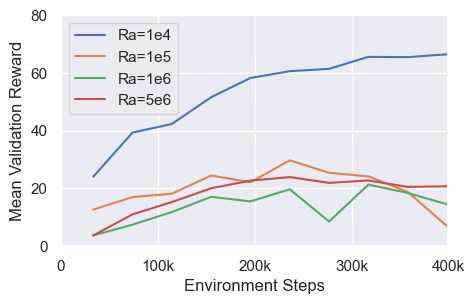

In [70]:
plt.figure(figsize=(5, 3))
sns.set_theme()

# x axis
plt.xlabel("Environment Steps")
plt.xlim(0, 1400)
xticks = [0, 350, 700, 1050, 1400]
labels = ["0", "100k", "200k", "300k", "400k"]
plt.xticks(xticks, labels)

# y axis
plt.ylabel("Mean Validation Reward")
plt.ylim(0, 80)

# plot data
labels = ["Ra=1e4", "Ra=1e5", "Ra=1e6", "Ra=5e6"]
for idx, r in enumerate(ra):
    sns.lineplot(data=df[f"reward_{r}"], x="Step", y=cs[f"reward_{r}"], label=labels[idx])

plt.legend()
#plt.show()
plt.savefig("/Users/tmarkmann/Downloads/out.svg")

## Nusselt

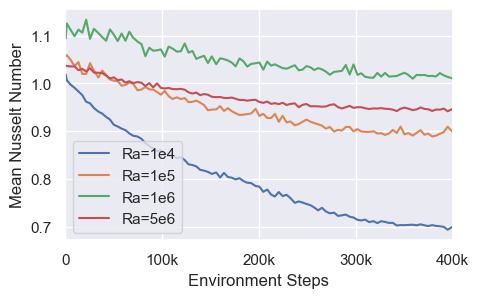

In [60]:
plt.figure(figsize=(5, 3))
sns.set_theme()

# x axis
plt.xlabel("Environment Steps")
plt.xlim(0, 1400)
xticks = [0, 350, 700, 1050, 1400]
labels = ["0", "100k", "200k", "300k", "400k"]
plt.xticks(xticks, labels)

# y axis
plt.ylabel("Mean Nusselt Number")
#plt.ylim(0, 0.3)

# plot data
labels = ["Ra=1e4", "Ra=1e5", "Ra=1e6", "Ra=5e6"]
for idx, r in enumerate(ra):
    df[f"nusselt_{r}"]["nusselt"] = df[f"nusselt_{r}"][cs[f"nusselt_{r}"]] / scale[idx]
    sns.lineplot(data=df[f"nusselt_{r}"], x="Step", y="nusselt", label=labels[idx])

#plt.legend()
#plt.show()
#plt.savefig("/Users/tmarkmann/Downloads/out.svg")